In [837]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
os.getcwd()
import time
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 120
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 80  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("../lib")) # N.B: NB needs this line to run locally!!
import xp as xp
from hamiltonian import inverse_weyl_transform
# import fixed_center_of_mass_exact_3D as fcm
# from plotting import plot_psi3D_fixedPsi, plot_psi3D_fixedPsi_multi, plot_psi3D_BO, fromgpu

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [752]:
ex3D = pd.read_pickle("3D_exact.pkl").sort_index(level=0)
ps3D = pd.read_pickle("3D_PS.pkl").sort_index(level=0)
ps3D_GR = pd.read_pickle("3D_PS_GammaR.pkl").sort_index(level=0)
ps3D_Jl = pd.read_pickle("3D_PS_Jl.pkl").sort_index(level=0)
ps3D_noERF = pd.read_pickle("3D_PS_NO_ERF.pkl").sort_index(level=0)
ps3D_lo = pd.read_pickle("3D_PSlo.pkl").sort_index(level=0)
# ex3D.drop(labels=(15,0), inplace=True)

ex2D = pd.read_pickle("2D_exact.pkl").sort_index(level=0)
ps2D = pd.read_pickle("2D_PS.pkl").sort_index(level=0)
ps2D_noERF = pd.read_pickle("2D_PS_NO_ERF.pkl").sort_index(level=0)

print(ex2D.columns)
print(ps3D.columns)
print(ps3D_noERF.columns)
Mass_ex = np.sort(np.unique(np.array(ex3D.index.to_list())[:,0]))
Mass_ps = np.sort(np.unique(np.array(ps3D.index.to_list())[:,0]))
Mass_psG = np.sort(np.unique(np.array(ps3D_GR.index.to_list())[:,0]))
Mass_Jl = np.sort(np.unique(np.array(ps3D_Jl.index.to_list())[:,0]))

Js_3D =  np.sort(np.unique(np.array(ps3D.index.to_list())[:,1]))
Js_2D =  np.sort(np.unique(np.array(ps2D.index.to_list())[:,1]))
print(Mass_ex)
print(Mass_Jl)
print(Js_3D, Js_2D)
# print(Mass_psG)

# print(ex3D)

Index(['gap', 'p01 z', 'p01 r', 'bond length', 'r00', 'r01', 'P01', 'lx00',
       'lx01', 'l200', 'l201'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO', 'lx00 PS', 'lx01 PS', 'l200 PS', 'l201 PS',
       'l200 BO', 'l201 BO', 'E0 BO', 'E0 PS'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO', 'lx00 PS', 'lx01 PS', 'l200 PS', 'l201 PS',
       'E0 BO', 'E0 PS'],
      dtype='object')
[  3.   4.   6.   8.  10.  15.  20.  30.  40.  60.  80. 100. 140. 180.
 220. 300.]
[  3.   4.   6.   8.  10.  15.  20.  30.  40.  60.  80. 100. 140. 180.
 220. 300.]
[0. 1. 2. 3. 4. 5. 6.] [   0.    1.    2.    3.    4.    5.    6.   10.   20.   50.  100.  500.
 1000.]


In [721]:
# bo_error = np.abs(ps3D_Jl['BO gap'] -ex3D['gap'])/ex3D['gap']
# ps_error = np.abs(ps3D_Jl['PS gap']-ex3D['gap'])/ex3D['gap']
# ps_no_erf_error = np.abs(ps3D_noERF['PS gap']-ex3D['gap'])/ex3D['gap']

## 3D
bo_error_3d = np.abs(ps3D['BO gap'] -ex3D['gap'])/ex3D['gap']
ps_error_3d = np.abs(ps3D['PS gap']-ex3D['gap'])/ex3D['gap']
ps_no_erf_error_3d = np.abs(ps3D_noERF['PS gap']-ex3D['gap'])/ex3D['gap']
ps_error_3d_lo = np.abs(ps3D_lo['PS gap']-ex3D['gap'])/ex3D['gap']

## 2D
bo_error_2d = np.abs(ps2D['BO gap']-ex2D['gap'])/ex2D['gap']
ps_error_2d = np.abs(ps2D['PS gap']-ex2D['gap'])/ex2D['gap']
ps_no_erf_error_2d = np.abs(ps2D_noERF['PS gap']-ex2D['gap'])/ex2D['gap']



<IPython.core.display.Javascript object>

/home/nb0817/.conda/envs/xebees/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nb0817/.conda/envs/xebees/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


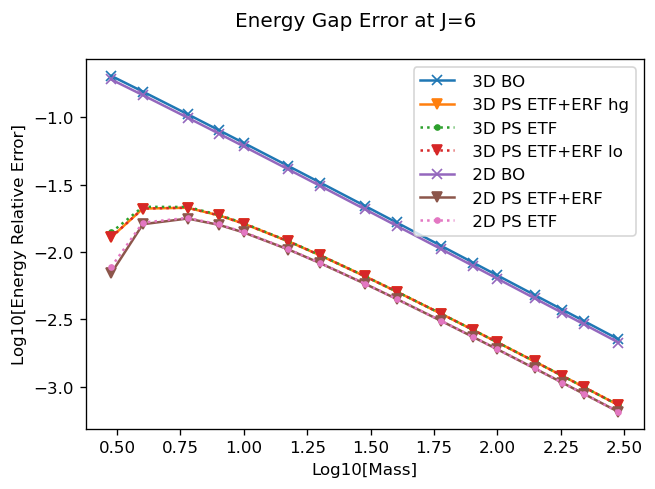

In [722]:
fig,ax = plt.subplots(figsize=(6,4))
Ji = 6
# ax.plot(xp.log10(Mass_ex), xp.log10(bo_error.loc[(slice(None),0)]),marker='x',label="BO")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_error.loc[(slice(None),0)]), marker='s',label="PS ETF+ERF")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error.loc[(slice(None),0)]), marker='s',label="PS ETF", linestyle=":")

ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_3d.loc[(slice(None),Ji)]),marker='x',label=" 3D BO")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_3d.loc[(slice(None),Ji)]), marker='v',label=" 3D PS ETF+ERF hg")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_3d.loc[(slice(None),Ji)]), marker='.',label=" 3D PS ETF", linestyle=":")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_3d.loc[(slice(None),Ji)]), marker='v',label=" 3D PS ETF+ERF lo",  linestyle=":")

ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_2d.loc[(slice(None),Ji)]),marker='x',label=" 2D BO")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_2d.loc[(slice(None),Ji)]), marker='v',label=" 2D PS ETF+ERF")
ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_2d.loc[(slice(None),Ji)]), marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(psG_error.loc[(slice(None),0)]), marker='.',label="PS w Gamma/R", linestyle="--")

ax.set_xlabel("Log10[Mass]")
ax.set_ylabel("Log10[Energy Relative Error]")
ax.legend()
fig.suptitle("Energy Gap Error at J={}".format(Ji))
display(fig)

<IPython.core.display.Javascript object>

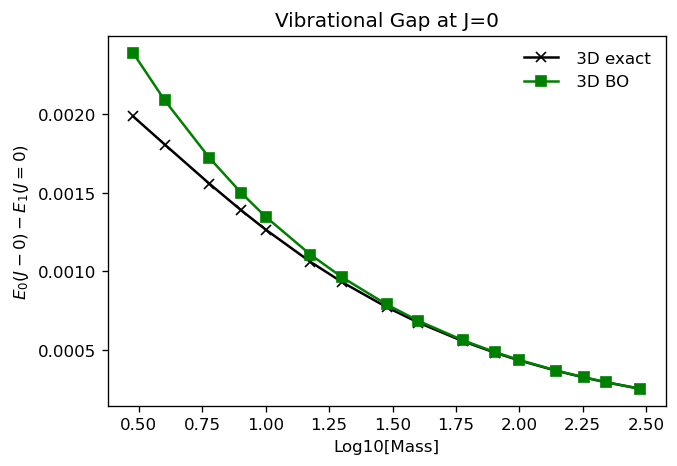

In [832]:
fig,ax = plt.subplots(figsize=(6,4))
Ji = 0

ax.plot(xp.log10(Mass_ex), ex3D['gap'].loc[(slice(None),Ji)],marker='x',color='k',label=" 3D exact")

# ax.plot(xp.log10(Mass_ex), ps3D['PS gap'].loc[(slice(None),Ji)], marker='v',label=" 3D PS ETF+ERF")
# ax.plot(xp.log10(Mass_ex), ps3D_noERF['PS gap'].loc[(slice(None),Ji)], marker='.',label=" 3D PS ETF")
ax.plot(xp.log10(Mass_ex), ps3D['BO gap'].loc[(slice(None),Ji)],marker='s',label=" 3D BO", color='green')
# ax.plot(xp.log10(Mass_ex), ex2D['gap'].loc[(slice(None),Ji)],marker='x',color='grey',label=" 2D exact", linestyle=":")
# ax.plot(xp.log10(Mass_ex), ps2D['BO gap'].loc[(slice(None),Ji)],marker='s',label=" 2D BO", linestyle=":")
# ax.plot(xp.log10(Mass_ex), ps2D['PS gap'].loc[(slice(None),Ji)], marker='v',label=" 2D PS ETF+ERF", linestyle=":")
# ax.plot(xp.log10(Mass_ex), ps2D_noERF['PS gap'].loc[(slice(None),Ji)], marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(bo_error_2d.loc[(slice(None),Ji)]),marker='x',label=" 2D BO")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_error_2d.loc[(slice(None),Ji)]), marker='v',label=" 2D PS ETF+ERF")
# ax.plot(xp.log10(Mass_ex), xp.log10(ps_no_erf_error_2d.loc[(slice(None),Ji)]), marker='.',label=" 2D PS ETF", linestyle=":")

# ax.plot(xp.log10(Mass_ex), xp.log10(psG_error.loc[(slice(None),0)]), marker='.',label="PS w Gamma/R", linestyle="--")

ax.set_xlabel("Log10[Mass]")
ax.set_ylabel("$E_0(J-0) - E_1(J=0)$")
# ax.set_ylabel("Log10[Energy Relative Error]")
ax.legend(frameon=False)
ax.set_title("Vibrational Gap at J={}".format(Ji))
display(fig)

<IPython.core.display.Javascript object>

/tmp/ipykernel_145736/2971188172.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
/tmp/ipykernel_145736/2971188172.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
/tmp/ipykernel_145736/2971188172.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(No

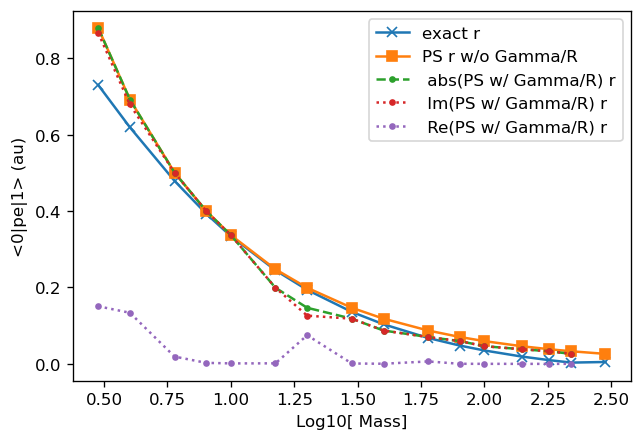

In [724]:
fig,ax = plt.subplots(figsize=(6,4))

ax.plot(np.log10(Mass_ex), np.abs(ex3D['p01 r'].loc[(slice(None),0)])   ,'x-',label='exact r')
ax.plot(np.log10(Mass_ps), np.abs(ps3D['momentum r'].loc[(slice(None),0)]),'s-',label="PS r w/o Gamma/R" )
ax.plot(np.log10(Mass_ps[:-1]), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
ax.plot(np.log10(Mass_ps[:-1]), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).real),'.-',label=" Re(PS w/ Gamma/R) r" , linestyle=":")

# ax.plot(np.log10(Mass_ps), np.abs(ps3D['momentum r'].loc[(slice(None),0)])- np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'s-',label="PS r w/o Gamma/R" )
# ax.plot(np.log10(Mass_ps), np.abs(ps3D_GR['momentum r'].loc[(slice(None),0)])-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" abs(PS w/ Gamma/R) r", linestyle="--")
# ax.plot(np.log10(Mass_ps), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).imag)-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" Im(PS w/ Gamma/R) r" , linestyle=":")
# # ax.plot(np.log10(Mass_ps), np.abs(np.array((ps3D_GR['momentum r'].loc[(slice(None),0)])).real)-np.abs(ex3D['p01 r'].loc[(slice(None),0)]),'.-',label=" Re(PS w/ Gamma/R) r" , linestyle=":")

# ax.set_ylim(-0.1,.9)
ax.set_xlabel("Log10[ Mass]")
ax.set_ylabel("<0|pe|1> (au)")
# ax.set_ylabel("<0|pe|1> Difference from exact")
ax.legend()

display(fig)

<IPython.core.display.Javascript object>

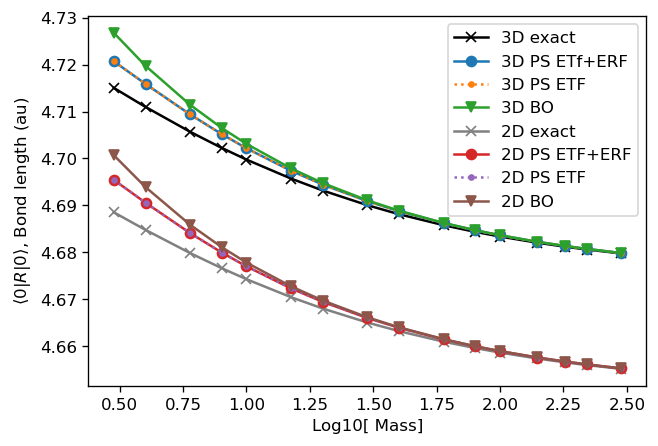

In [725]:
fig,ax = plt.subplots(figsize=(6,4))

ax.plot(np.log10(Mass_ex), np.abs(ex3D['bond length'].loc[(slice(None),0)]),'x-',color='k', label="3D exact")
ax.plot(np.log10(Mass_ps), np.abs(ps3D['bond length PS'].loc[(slice(None),0)]),'o-', label="3D PS ETf+ERF")
ax.plot(np.log10(Mass_ps), np.abs(ps3D_noERF['bond length PS'].loc[(slice(None),0)]),'.:', label="3D PS ETF")
ax.plot(np.log10(Mass_ps), np.abs(ps3D['bond length BO'].loc[(slice(None),0)]),'v-', label="3D BO")

ax.plot(np.log10(Mass_ex), np.abs(ex2D['bond length'].loc[(slice(None),0)]),'x-',color='grey', label="2D exact")
ax.plot(np.log10(Mass_ps), np.abs(ps2D['bond length PS'].loc[(slice(None),0)]),'o-', label="2D PS ETF+ERF")
ax.plot(np.log10(Mass_ps), np.abs(ps2D_noERF['bond length PS'].loc[(slice(None),0)]),'.:', label="2D PS ETF")
ax.plot(np.log10(Mass_ps), np.abs(ps2D['bond length BO'].loc[(slice(None),0)]),'v-', label="2D BO")



ax.set_xlabel("Log10[ Mass]")
ax.set_ylabel(r"$\langle0|R|0\rangle$, Bond length (au)")
ax.legend()

display(fig)

<IPython.core.display.Javascript object>

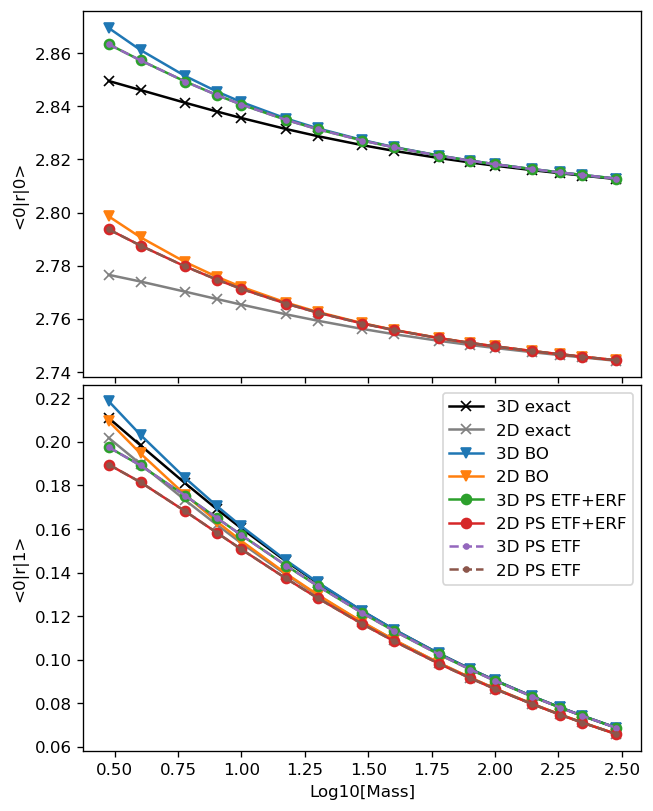

In [726]:
fig,ax = plt.subplots(nrows=2, figsize=(6,8), sharex=True)
Ji=0
ax[0].plot(np.log10(Mass_ex), np.abs(ex3D['r00'].loc[(slice(None),Ji)]),'x-', label="3Dexact", color='k')
ax[1].plot(np.log10(Mass_ex), np.abs(ex3D['r01'].loc[(slice(None),Ji)]),'x-', label="3D exact", color='k')
ax[0].plot(np.log10(Mass_ex), np.abs(ex2D['r00'].loc[(slice(None),Ji)]),'x-', label="2Dexact", color='grey')
ax[1].plot(np.log10(Mass_ex), np.abs(ex2D['r01'].loc[(slice(None),Ji)]),'x-', label="2D exact", color='grey')

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")

ax[1].set_xlabel("Log10[Mass]")
ax[0].set_ylabel("<0|r|0>")
ax[1].set_ylabel("<0|r|1>")

ax[1].legend()
fig.subplots_adjust(hspace=0.02)
display(fig)

<IPython.core.display.Javascript object>

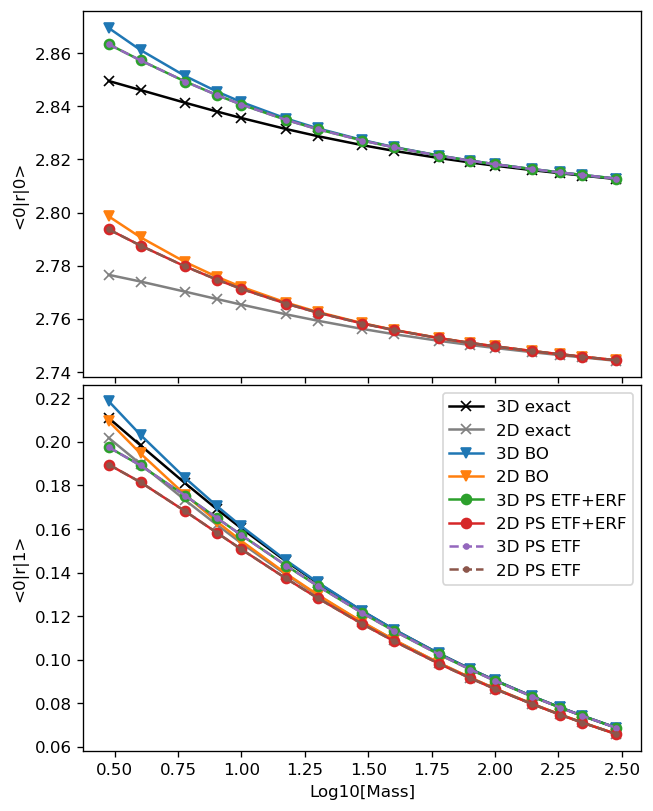

In [726]:
fig,ax = plt.subplots(nrows=2, figsize=(6,8), sharex=True)
Ji=0
ax[0].plot(np.log10(Mass_ex), np.abs(ex3D['r00'].loc[(slice(None),Ji)]),'x-', label="3Dexact", color='k')
ax[1].plot(np.log10(Mass_ex), np.abs(ex3D['r01'].loc[(slice(None),Ji)]),'x-', label="3D exact", color='k')
ax[0].plot(np.log10(Mass_ex), np.abs(ex2D['r00'].loc[(slice(None),Ji)]),'x-', label="2Dexact", color='grey')
ax[1].plot(np.log10(Mass_ex), np.abs(ex2D['r01'].loc[(slice(None),Ji)]),'x-', label="2D exact", color='grey')

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="3D BO")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 BO'].loc[(slice(None),Ji)]),'v-', label="2D BO")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="3D PS ETF+ERF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D['r00 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D['r01 PS'].loc[(slice(None),Ji)]),'o-', label="2D PS ETF+ERF")

ax[0].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps3D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="3D PS ETF")
ax[0].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r00 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")
ax[1].plot(np.log10(Mass_Jl), np.abs(ps2D_noERF['r01 PS'].loc[(slice(None),Ji)]),'.--', label="2D PS ETF")

ax[1].set_xlabel("Log10[Mass]")
ax[0].set_ylabel("<0|r|0>")
ax[1].set_ylabel("<0|r|1>")

ax[1].legend()
fig.subplots_adjust(hspace=0.02)
display(fig)

<IPython.core.display.Javascript object>

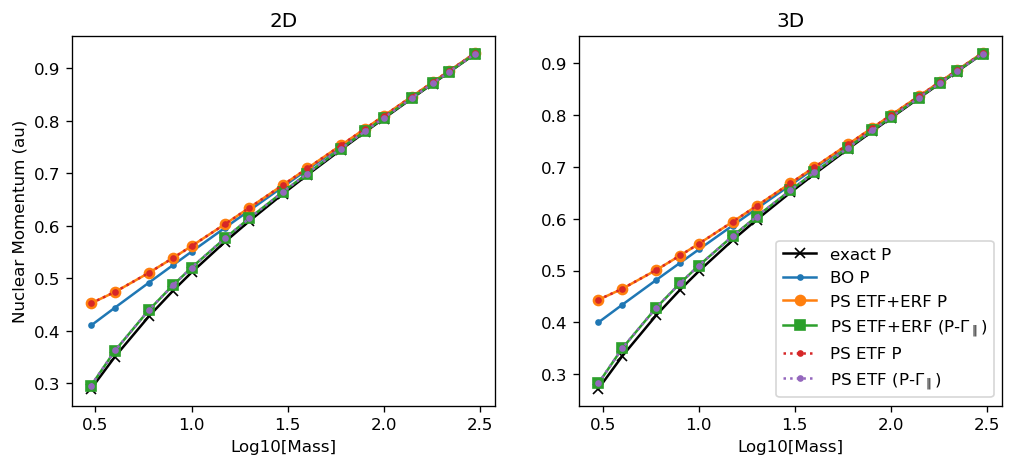

In [727]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
Ji = 6
ax[1].plot(xp.log10(Mass_ex), np.log10(ex3D['P01'].loc[(slice(None),Ji)]), 'x-', label="exact P", color='k')
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 BO'].loc[(slice(None),Ji)]), '.-', label="BO P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label="PS ETF+ERF P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P-$\Gamma_\parallel$)")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label="PS ETF P")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P-$\Gamma_\parallel$)")

ax[0].plot(xp.log10(Mass_ex), np.log10(ex2D['P01'].loc[(slice(None),Ji)]), 'x-', label="exact P", color='k')
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 BO'].loc[(slice(None),Ji)]), '.-', label="BO P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label="PS ETF+ERF P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P-$\Gamma_\parallel$)")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label="PS ETF P")
ax[0].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P-$\Gamma_\parallel$)")

ax[0].set_title("2D")
ax[1].set_title("3D")
ax[0].set_xlabel("Log10[Mass]")
ax[0].set_ylabel("Nuclear Momentum (au)")
ax[1].set_xlabel("Log10[Mass]")
ax[1].legend()
display(fig)

<IPython.core.display.Javascript object>

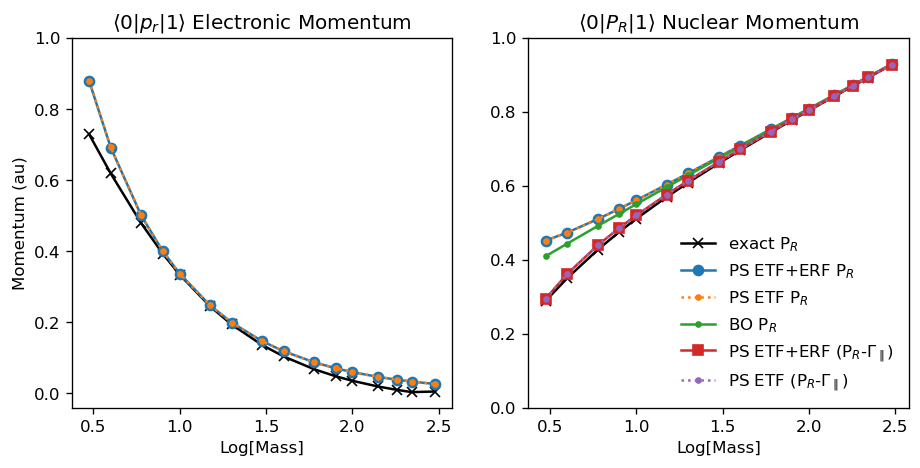

In [828]:
fig, ax = plt.subplots(ncols=2, figsize=(9,4), sharex=True)
Ji = 6
# ax[1].plot(xp.log10(Mass_ex), np.log10(ex3D['P01'].loc[(slice(None),Ji)]), 'x-', label="exact P", color='k')
# ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 BO'].loc[(slice(None),Ji)]), '.-', label="BO P")
# ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label="PS ETF+ERF P")
# ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P-$\Gamma_\parallel$)")
# ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label="PS ETF P")
# ax[1].plot(xp.log10(Mass_Jl), np.log10(ps3D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P-$\Gamma_\parallel$)")
ax[0].plot(np.log10(Mass_ex), xp.abs(ex3D['p01 r'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['momentum r'].loc[(slice(None)),Ji])), 'o-', label='PS ETF+ERF')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['momentum r'].loc[(slice(None)),Ji])), '.:', label='PS ETF')

ax[1].plot(xp.log10(Mass_ex), np.log10(ex2D['P01'].loc[(slice(None),Ji)]), 'x-', label=r"exact P$_R$", color='k')
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 PS'].loc[(slice(None),Ji)]), 'o-', label=r"PS ETF+ERF P$_R$")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['P01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF P$_R$")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps2D['P01 BO'].loc[(slice(None),Ji)]), '.-', label=r"BO P$_R$")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps2D['(P-G)01 PS'].loc[(slice(None),Ji)]), 's-', label=r"PS ETF+ERF (P$_R$-$\Gamma_\parallel$)")
ax[1].plot(xp.log10(Mass_Jl), np.log10(ps2D_noERF['(P-G)01 PS'].loc[(slice(None),Ji)]), '.:', label=r"PS ETF (P$_R$-$\Gamma_\parallel$)")


ax[1].set_xlabel("Log[Mass]")
ax[0].set_ylabel("Momentum (au)")
ax[0].set_xlabel("Log[Mass]")
ax[1].set_title(r"$\langle 0|P_R|1\rangle$ Nuclear Momentum")
ax[0].set_title(r"$\langle 0|p_r|1\rangle$ Electronic Momentum")
ax[0].set_yticks(xp.linspace(0,1,6))
ax[1].set_yticks(xp.linspace(0,1,6))

# ax[1].set_xlabel("Log10[Mass]")
ax[1].legend(frameon=False)
display(fig)

<IPython.core.display.Javascript object>

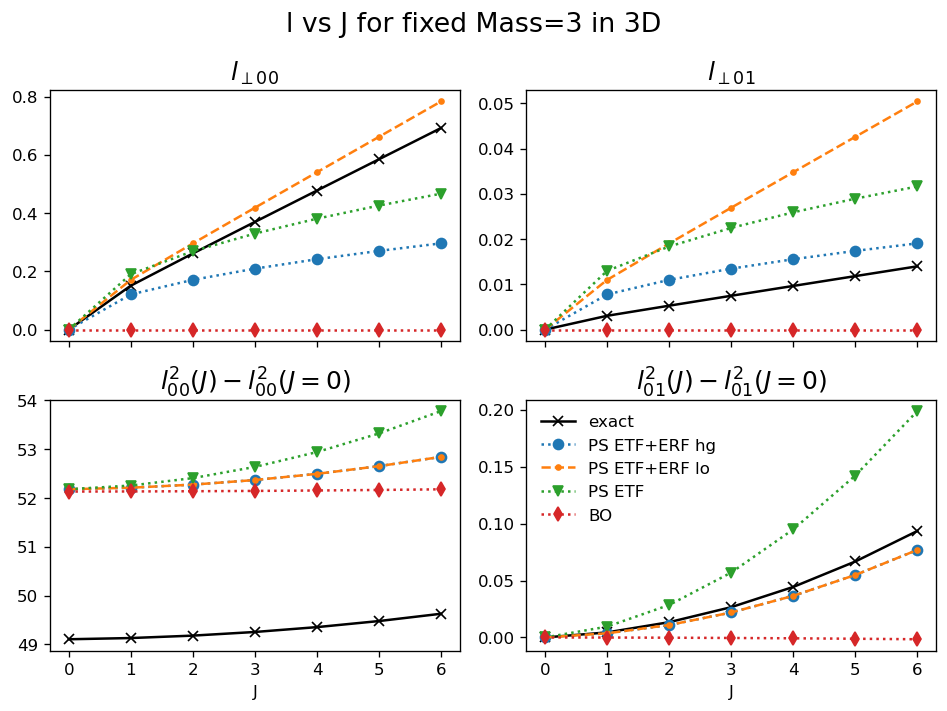

In [930]:
fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(8,6))
M=3

fig.suptitle("l vs J for fixed Mass={} in 3D".format(M), fontsize=16)
ax[0,0].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), '.--', label='3D PS ETF+ERF lo')
ax[0,0].plot(Js_3D , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
ax[0,0].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

# ax[0,0].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), '.--', label='3D PS ETF+ERF lo')
# ax[0,0].plot(Js_3D , (xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
# ax[0,0].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

# ax[0,0].plot(Js_2D, ex2D['lx00'].loc[(M,slice(None))], 'x-', label='2D exact', color='grey')
# ax[0,0].plot(Js_2D , xp.abs(xp.asarray(ps2D['lx00 PS'].loc[(M,slice(None))]).real), '.-', label='3D PS ETF+ERF')
# ax[0,0].plot(Js_2D , xp.abs(xp.asarray(ps2D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v-', label='PS ETF')

ax[0,1].plot(Js_ps, xp.abs(ex3D['lx01'].loc[(10,slice(None))]), 'x-', label='exact', color='k')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['lx01 PS'].loc[(M,slice(None))]).real), 'o:', label='PS ETF+ERF hg')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['lx01 PS'].loc[(M,slice(None))]).real), '.--', label='PS ETF+ERF lo')
ax[0,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['lx01 PS'].loc[(M,slice(None))]).real), 'v:', label='PS ETF')
ax[0,1].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')

# ax[1,0].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))] -ex3D['l200'].loc[(M,0)], 'x-', label='exact', color='k')
# ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 PS'].loc[(M,slice(None))]).real)-(ps3D['l200 PS'].loc[(M,0)]), 'o:', label='PS ETF+ERF hg')
# ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_lo['l200 PS'].loc[(M,0)]), '.--', label='PS ETF+ERF lo')
# ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real)-(ps3D_noERF['l200 PS'].loc[(M,0)]), 'v:', label='PS ETF')
# ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 BO'].loc[(M,slice(None))]).real)-(ps3D['l200 BO'].loc[(M,0)]), 'd:', label='BO')
# # ax[1,0].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))]-ex3D['l200'].loc[(M,0)], 'x-', label='exact')
# # ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real)-ex3D['l200'].loc[(M,0)], '.-', label='PS ETF')

ax[1,0].plot(Js_ps, ex3D['l200'].loc[(M,slice(None))], 'x-', label='exact', color='k')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 PS'].loc[(M,slice(None))]).real), 'o:', label='PS ETF+ERF hg')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_lo['l200 PS'].loc[(M,slice(None))]).real), '.--', label='PS ETF+ERF lo')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,slice(None))]).real), 'v:', label='PS ETF')
ax[1,0].plot(Js_ps , xp.abs(xp.asarray(ps3D['l200 BO'].loc[(M,slice(None))]).real), 'd:', label='BO')

ax[1,1].plot(Js_ps, xp.abs(ex3D['l201'].loc[(M,slice(None))])-ex3D['l201'].loc[(M,0)], 'x-', label='exact', color='k')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D['l201 PS'].loc[(M,0)]), 'o:', label='PS ETF+ERF hg')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D_lo['l201 PS'].loc[(M,0)]), '.--', label='PS ETF+ERF lo')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l201 PS'].loc[(M,slice(None))]).real)-xp.abs(ps3D_noERF['l201 PS'].loc[(M,0)]), 'v:', label='PS ETF')
ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D['l201 BO'].loc[(M,slice(None))]).real)-xp.abs((ps3D['l201 BO'].loc[(M,0)])), 'd:', label='BO')

# ax[1,1].plot(Js_ps, xp.abs(ex3D['l201'].loc[(M,slice(None))])-ex3D['l200'].loc[(M,0)], 'x-', label='exact')
# ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_Jl['l201 PS'].loc[(M,slice(None))]).real)-ex3D['l201'].loc[(M,0)], '.-', label='PS ETF+ERF')
# ax[1,1].plot(Js_ps , xp.abs(xp.asarray(ps3D_noERF['l201 PS'].loc[(M,slice(None))]).real)-ex3D['l201'].loc[(M,0)], 'v-', label='PS ETF')

ax[0,0].set_title(r"$l_{\perp 00}$", fontsize=15)
ax[0,1].set_title(r"$l_{\perp 01}$", fontsize=15)
ax[1,0].set_title(r"$l^2_{00}(J) - l^2_{00}(J=0)$", fontsize=15)
ax[1,1].set_title(r"$l^2_{01}(J) - l^2_{01}(J=0)$", fontsize=15)
ax[1,0].set_xlabel("J")
ax[1,1].set_xlabel("J")
ax[1,0].set_xticks(Js_3D)
ax[1,1].set_xticks(Js_3D)
ax[1,1].legend(frameon=False)
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

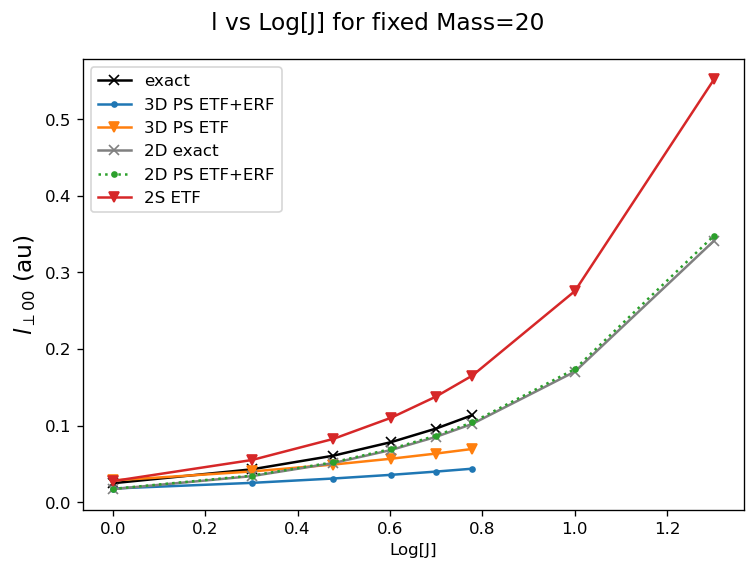

In [729]:
# fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True)
fig,ax = plt.subplots()
M=20

fig.suptitle("l vs Log[J] for fixed Mass={}".format(M), fontsize=14)
ax.plot(xp.log10(Js_3D[1:]), ex3D['lx00'].loc[(M,Js_3D[1:])], 'x-', label='exact', color='k')
ax.plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_Jl['lx00 PS'].loc[(M,Js_3D[1:])]).real), '.-', label='3D PS ETF+ERF')
ax.plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,Js_3D[1:])]).real), 'v-', label='3D PS ETF')

ax.plot(xp.log10(Js_2D[1:-4]), xp.abs(ex2D['lx00'].loc[(M,Js_2D[1:-4])]), 'x-', label='2D exact', color='grey')
ax.plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D['lx00 PS'].loc[(M,Js_2D[1:-4])]).real), '.:', label='2D PS ETF+ERF')
ax.plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D_noERF['lx00 PS'].loc[(M,Js_2D[1:-4])]).real), 'v-', label='2S ETF')

ax.set_ylabel(r"$l_{\perp 00}$ (au)", fontsize=14)
# ax[0,1].set_title(r"$l_{x01}$")
# ax[1,0].set_title(r"$l^2_{00}$")
# ax[1,1].set_title(r"$l^2_{01}$")
ax.set_xlabel("Log[J]")
# ax.set_xlabel("J")
ax.legend()
fig.tight_layout()
display(fig)

<IPython.core.display.Javascript object>

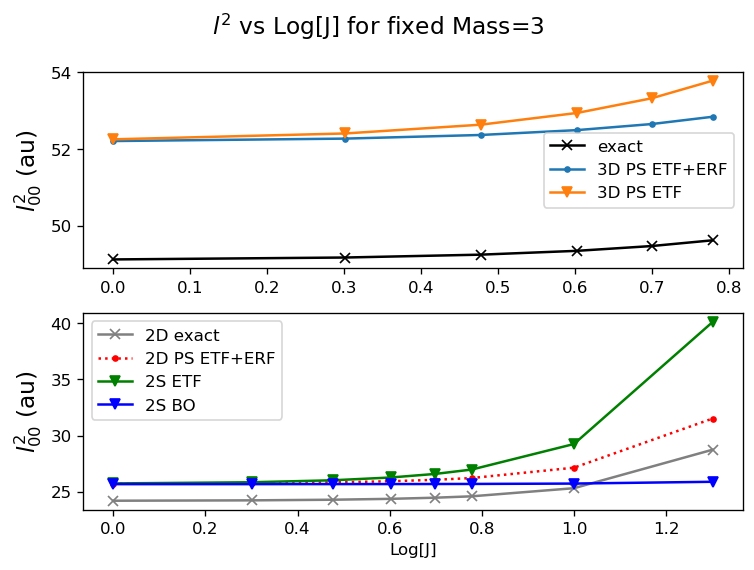

In [836]:
fig,ax = plt.subplots(nrows=2)
M=3

fig.suptitle(r"$l^2$ vs Log[J] for fixed Mass={}".format(M), fontsize=14)
ax[0].plot(xp.log10(Js_3D[1:]), ex3D['l200'].loc[(M,Js_3D[1:])], 'x-', label='exact', color='k')
ax[0].plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_Jl['l200 PS'].loc[(M,Js_3D[1:])]).real), '.-', label='3D PS ETF+ERF')
ax[0].plot(xp.log10(Js_3D[1:]) , xp.abs(xp.asarray(ps3D_noERF['l200 PS'].loc[(M,Js_3D[1:])]).real), 'v-', label='3D PS ETF')

ax[1].plot(xp.log10(Js_2D[1:-4]), xp.abs(ex2D['l200'].loc[(M,Js_2D[1:-4])]), 'x-', label='2D exact', color='grey')
ax[1].plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D['l200 PS'].loc[(M,Js_2D[1:-4])]).real), '.:', label='2D PS ETF+ERF', color='r')
ax[1].plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D_noERF['l200 PS'].loc[(M,Js_2D[1:-4])]).real), 'v-', label='2S ETF', color='g')
ax[1].plot(xp.log10(Js_2D[1:-4]) , xp.abs(xp.asarray(ps2D_noERF['l200 BO'].loc[(M,Js_2D[1:-4])]).real), 'v-', label='2S BO', color='b')

ax[0].set_ylabel(r"$l^2_{00}$ (au)", fontsize=14)
ax[1].set_ylabel(r"$l^2_{00}$ (au)", fontsize=14)
# ax[0,1].set_title(r"$l_{x01}$")
# ax[1,0].set_title(r"$l^2_{00}$")
# ax[1,1].set_title(r"$l^2_{01}$")
ax[1].set_xlabel("Log[J]")
# ax.set_xlabel("J")
ax[0].legend()
ax[1].legend()
fig.tight_layout()
display(fig)

In [747]:
fig,ax = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(8,6))
Ji=0
fig.suptitle("l vs Log[Mass] for fixed J={}".format(Ji), fontsize=16)
ax[0,0].plot(np.log10(Mass_ex), xp.abs(ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
ax[0,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[0,0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")

# ax[0,0].plot(np.log10(Mass_ex), (ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
# ax[0,0].plot(np.log10(Mass_Jl) , (list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')

ax[0,0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label=
ax[0,1].plot(np.log10(Mass_ex), xp.abs(ex3D['lx01'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx01 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx01 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF hg')
ax[0,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx01 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[0,1].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")

# # ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex3D['l200'].loc[(slice(None),Ji)])-xp.abs(ex3D['l200'].loc[(300,Ji)]), 'x-', label='exact', color='k')
# # ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex2D['l200'].loc[(slice(None),Ji)])-xp.abs(ex2D['l200'].loc[(300,Ji)]), 'x-', label='exact', color='purple')
# ax[1,0].plot(np.log10(Mass_ex), xp.abs(ex3D['l200'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['l200 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
# ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['l200 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[1,0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l200 BO'].loc[(slice(None)),Ji])), 'd:', label='PS ETF+ERF hg')

# ax[1,1].plot(np.log10(Mass_ex), xp.abs(ex3D['l201'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l201 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
# ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['l201 PS'].loc[(slice(None)),Ji])), '.--', label='PS ETF+ERF lo')
# ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['l201 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
# ax[1,1].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['l201 BO'].loc[(slice(None)),Ji])), 'd:', label='BO')

# print(Mass_Jl)
# print(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])

ax[0,0].set_title(r"$l_{\perp 00}$", fontsize=14)
ax[0,1].set_title(r"$l_{\perp 01}$", fontsize=14)
ax[1,0].set_title(r"$l^2_{00}$", fontsize=14)
ax[1,1].set_title(r"$l^2_{01}$", fontsize=14)
ax[1,0].set_xlabel("Log[Mass]")
ax[1,1].set_xlabel("Log[Mass]")
ax[0,1].legend(frameon=False)
fig.tight_layout()
display(fig)

SyntaxError: '(' was never closed (3246407197.py, line 15)

<IPython.core.display.Javascript object>

Mass
3      0.783340+0.000000j
4      0.585447+0.000000j
6      0.388813+0.000000j
8      0.290984+0.000000j
10     0.232455+0.000000j
15     0.154633+0.000000j
20     0.115827+0.000000j
30     0.077102+0.000000j
40     0.057775+0.000000j
60     0.038475+0.000000j
80     0.028837+0.000000j
100    0.023059+0.000000j
140    0.016460+0.000000j
180    0.012797+0.000000j
220    0.010466+0.000000j
300    0.007671+0.000000j
Name: lx00 PS, dtype: complex128


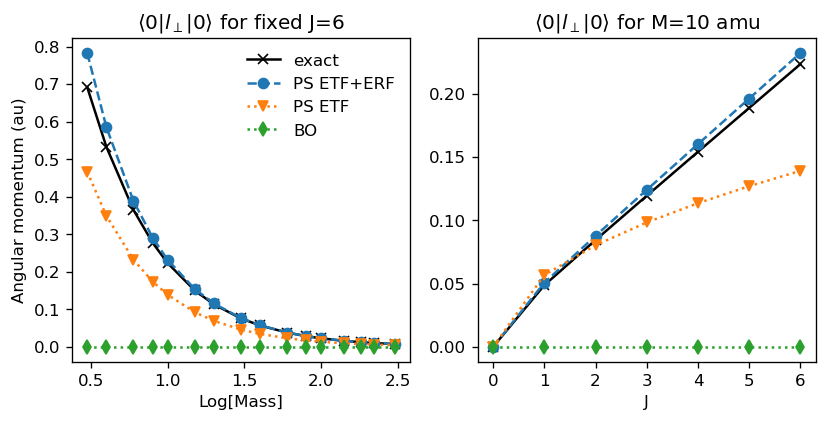

In [767]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3.5))
Ji=6
M=10
# fig.suptitle("l vs Log[Mass] for fixed J={}".format(Ji), fontsize=16)
ax[0].plot(np.log10(Mass_ex), xp.abs(ex3D['lx00'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
# # ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D['lx00 PS'].loc[(slice(None)),Ji])), 'o:', label='PS ETF+ERF hg')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])), 'o--', label='PS ETF+ERF')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['lx00 PS'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")
ax[0].set_title(r"$\langle 0 | l_\perp|0\rangle$ for fixed J=6")
ax[0].set_xlabel("Log[Mass]")
ax[0].set_ylabel("Angular momentum (au)")

ax[1].plot(Js_3D, ex3D['lx00'].loc[(M,slice(None))], 'x-', label='exact', color='k')
# ax[1].plot(Js_3D , xp.abs(xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
ax[1].plot(Js_3D , xp.abs(xp.asarray(ps3D_lo['lx00 PS'].loc[(M,slice(None))]).real), 'o--', label='3D PS ETF+ERF')
ax[1].plot(Js_3D , xp.abs(xp.asarray(ps3D_noERF['lx00 PS'].loc[(M,slice(None))]).real), 'v:', label='3D PS ETF')
ax[1].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')
ax[1].set_title(r"$\langle 0 | l_\perp|0\rangle$ for M=10 amu")
ax[1].set_xlabel("J")
ax[1].set_xticks(range(7))


ax[0].legend(frameon=False)
print(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])

display(fig)

In [733]:
ex3D['lx00'].loc[(220,Js_3D[1:])]

Mass  J  
220   1.0    0.002275+0.000000j
      2.0    0.003960+0.000000j
      3.0    0.005584+0.000000j
      4.0    0.007207+0.000000j
      5.0    0.008831+0.000000j
      6.0    0.010448+0.000000j
Name: lx00, dtype: complex128

<IPython.core.display.Javascript object>

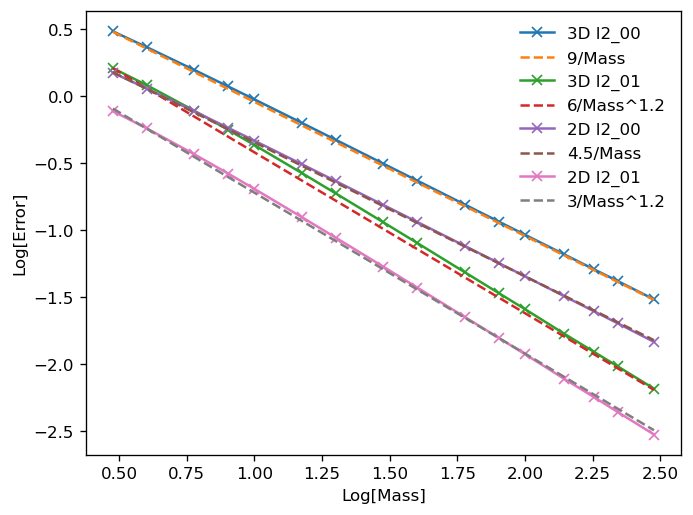

In [734]:
fig,ax = plt.subplots()

ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 BO'].loc[(Mass_ps,0)]), 'x-', label="3D l2_00")
# ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 PS'].loc[(Mass_ps,0)]), 'x-')
ax.plot(xp.log10(Mass_ex), xp.log10(9/Mass_ex), '--', label="9/Mass")

ax.plot(xp.log10(Mass_ex), xp.log10(-1*(xp.abs(ex3D['l201'].loc[(Mass_ex, 0)])-xp.abs(ps3D['l201 BO'].loc[(Mass_ps,0)]))), 'x-', label="3D l2_01")
ax.plot(xp.log10(Mass_ex), xp.log10(6/Mass_ex**1.2), '--', label="6/Mass^1.2")

ax.plot(xp.log10(Mass_ex), xp.log10(-1*(xp.abs(ex2D['l200'].loc[(Mass_ex, 0)])-xp.abs(ps2D['l200 BO'].loc[(Mass_ps,0)]))), 'x-', label="2D l2_00")
ax.plot(xp.log10(Mass_ex), xp.log10(4.5/Mass), '--', label="4.5/Mass")

ax.plot(xp.log10(Mass_ex), xp.log10(-1*(xp.abs(ex2D['l201'].loc[(Mass_ex, 0)])-xp.abs(ps2D['l201 BO'].loc[(Mass_ps,0)]))), 'x-', label="2D l2_01")
ax.plot(xp.log10(Mass_ex), xp.log10(3/Mass_ex**1.2), '--', label="3/Mass^1.2")

ax.set_xlabel("Log[Mass]")
ax.set_ylabel("Log[Error]")

ax.legend(frameon=False)
# ax.set_ylabel
display(fig)

In [735]:
ex3D['l200'].loc[(Mass_ex, 0)]/ex2D['l200'].loc[(Mass_ex, 0)]

Mass  J  
3     0.0    2.030174+0.000000j
4     0.0    2.030243+0.000000j
6     0.0    2.030320+0.000000j
8     0.0    2.030362+0.000000j
10    0.0    2.030385+0.000000j
15    0.0    2.030421+0.000000j
20    0.0    2.030439+0.000000j
30    0.0    2.030463+0.000000j
40    0.0    2.030473+0.000000j
60    0.0    2.030494+0.000000j
80    0.0    2.030505+0.000000j
100   0.0    2.030516+0.000000j
140   0.0    2.030533+0.000000j
180   0.0    2.030543+0.000000j
220   0.0    2.030550+0.000000j
300   0.0    2.030568+0.000000j
Name: l200, dtype: complex128

In [736]:
xp.log10(-1*(xp.abs(ex3D['l201'].loc[(Mass_ex, 0)])-xp.abs(ps3D['l201 BO'].loc[(Mass_ps,0)])))

Mass  J  
3     0.0    0.205840
4     0.0    0.079304
6     0.0   -0.111862
8     0.0   -0.254176
10    0.0   -0.367545
15    0.0   -0.577357
20    0.0   -0.728852
30    0.0   -0.944474
40    0.0   -1.098388
60    0.0   -1.317004
80    0.0   -1.472018
100   0.0   -1.591724
140   0.0   -1.776435
180   0.0   -1.910643
220   0.0   -2.018225
300   0.0   -2.185245
dtype: float64

In [737]:
ex3D_te = pd.read_pickle("3D_te.pkl").sort_index(level=0)
ps3D_te = pd.read_pickle("3D_PS_te.pkl").sort_index(level=0)
Mass_te = np.sort(np.unique(np.array(ps3D_te.index.to_list())[:,0]))
print(Mass_te)

[  6.  10.  30.  60. 100. 300.]


<IPython.core.display.Javascript object>

[ 2.44948117  3.16226027  5.47714068  7.74573045  9.99949504 17.31790193]


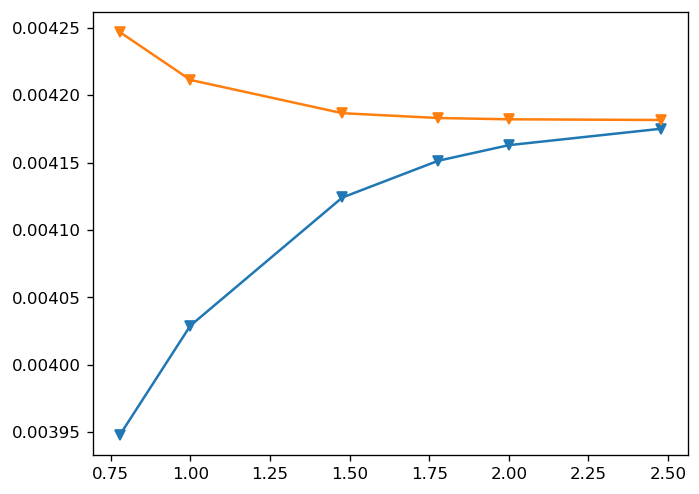

In [906]:
fig,ax = plt.subplots()

# ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 BO'].loc[(Mass_ps,0)]), 'x-', label="3D l2_00")
# # ax.plot(xp.log10(Mass_ex), xp.log10(ex3D['l200'].loc[(Mass_ex, 0)]-ps3D['l200 PS'].loc[(Mass_ps,0)]), 'x-')
# ax.plot(xp.log10(Mass_ex), xp.log10(9/Mass_ex), '--', label="9/Mass")

# ax.plot(xp.log10(Mass_te), xp.log10(ex3D_te['Te 00'].loc[(Mass_te,0)]-ps3D_te['Te 00 BO'].loc[(Mass_te,0)]), 'v-')
# ax.plot(xp.log10(Mass_te), xp.log10(ex3D_te['Te 00'].loc[(Mass_te,0)]-ps3D_te['Te 00 PS'].loc[(Mass_te,0)]), 'v-')
mu = xp.sqrt(1e6*Mass_te*1/(1e6+Mass_te+1))
print(mu)

ax.plot(xp.log10(Mass_te), xp.abs(ex3D_te['Te 00'].loc[(Mass_te,0)]), 'v-')
ax.plot(xp.log10(Mass_te), xp.abs(ps3D_te['Te 00 PS'].loc[(Mass_te,0)]), 'v-')



display(fig)

In [785]:
Ji=6
rot_gap_ex = xp.asarray(ex3D['E0'].loc[(Mass_ex,Ji)]) -xp.asarray(ex3D['E0'].loc[(Mass_ex,0)])
rot_gap_bo = xp.asarray(ps3D['E0 BO'].loc[(Mass_ps,Ji)]) -xp.asarray(ps3D['E0 BO'].loc[(Mass_ps,0)])
rot_gap_ps_hg = xp.asarray(ps3D['E0 PS'].loc[(Mass_ps,Ji)]) -xp.asarray(ps3D['E0 PS'].loc[(Mass_ps,0)])
rot_gap_ps_lo = xp.asarray(ps3D_lo['E0 PS'].loc[(Mass_ps,Ji)]) -xp.asarray(ps3D_lo['E0 PS'].loc[(Mass_ps,0)])
rot_gap_ps_noerf = xp.asarray(ps3D_noERF['E0 PS'].loc[(Mass_ps,Ji)]) -xp.asarray(ps3D_noERF['E0 PS'].loc[(Mass_ps,0)])

print(rot_gap_ex)
print(rot_gap_bo)
print(rot_gap_ps_hg)
print(rot_gap_ps_lo)
print(rot_gap_ps_noerf)

[-1.5496e-04+0.j -1.1956e-04+0.j -8.2090e-05+0.j -6.2510e-05+0.j
 -5.0490e-05+0.j -3.4090e-05+0.j -2.5740e-05+0.j -1.7280e-05+0.j
 -1.3000e-05+0.j -8.7000e-06+0.j -6.5400e-06+0.j -5.2400e-06+0.j
 -3.7500e-06+0.j -2.9200e-06+0.j -2.3900e-06+0.j -1.7500e-06+0.j]
[-1.726567e-04+0.j -1.298000e-04+0.j -8.679000e-05+0.j -6.520000e-05+0.j
 -5.221000e-05+0.j -3.488000e-05+0.j -2.619000e-05+0.j -1.748000e-05+0.j
 -1.312000e-05+0.j -8.750000e-06+0.j -6.570000e-06+0.j -5.260000e-06+0.j
 -3.760000e-06+0.j -2.920000e-06+0.j -2.390000e-06+0.j -1.760000e-06+0.j]
[-1.5216e-04+0.j -1.1826e-04+0.j -8.1650e-05+0.j -6.2310e-05+0.j
 -5.0370e-05+0.j -3.4050e-05+0.j -2.5720e-05+0.j -1.7270e-05+0.j
 -1.3000e-05+0.j -8.7000e-06+0.j -6.5400e-06+0.j -5.2400e-06+0.j
 -3.7400e-06+0.j -2.9200e-06+0.j -2.3900e-06+0.j -1.7500e-06+0.j]
[-1.5216e-04+0.j -1.1826e-04+0.j -8.1650e-05+0.j -6.2310e-05+0.j
 -5.0360e-05+0.j -3.4050e-05+0.j -2.5720e-05+0.j -1.7270e-05+0.j
 -1.3000e-05+0.j -8.7000e-06+0.j -6.5400e-06+0.j -5.240

<IPython.core.display.Javascript object>

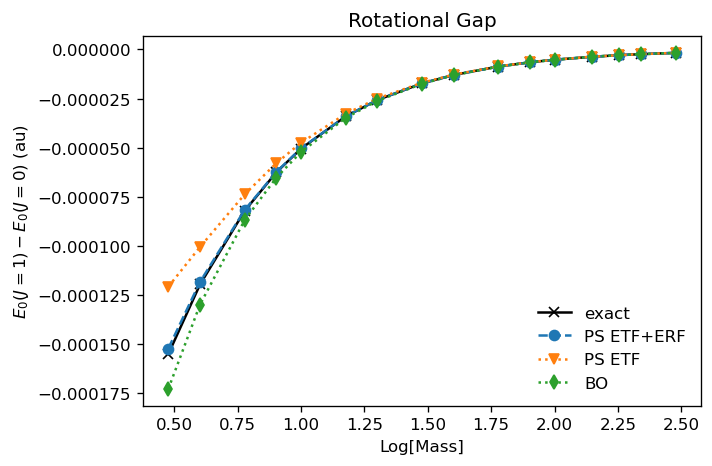

In [786]:
fig,ax = plt.subplots(figsize=(6,4))

ax.plot(xp.log10(Mass_ex), rot_gap_ex, 'x-', color='k', label='exact')
# ax.plot(xp.log10(Mass_ps), rot_gap_ps_hg, 'o:', label='PS ETF+ERF hg')
ax.plot(xp.log10(Mass_ps), rot_gap_ps_lo, 'o--', label='PS ETF+ERF')
ax.plot(xp.log10(Mass_ps), rot_gap_ps_noerf, 'v:', label="PS ETF")
ax.plot(xp.log10(Mass_ps), rot_gap_bo, "d:", label="BO")

ax.set_xlabel("Log[Mass]")
ax.set_ylabel(r"$E_0(J=1) - E_0(J=0)$ (au)")
ax.set_title("Rotational Gap")
ax.legend(frameon=False)
display(fig)

<IPython.core.display.Javascript object>

/tmp/ipykernel_145736/762896209.py:4: RuntimeWarning: divide by zero encountered in log10
  ax.plot(xp.log10(Mass_ps), xp.log10((rot_gap_ps_hg - rot_gap_ex)/rot_gap_ex), 'o:', label='PS ETF+ERF hg')
/tmp/ipykernel_145736/762896209.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_ps_lo- rot_gap_ex)/rot_gap_ex), '.--', label='PS ETF+ERF lo')
/tmp/ipykernel_145736/762896209.py:6: RuntimeWarning: divide by zero encountered in log10
  ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_ps_noerf- rot_gap_ex)/rot_gap_ex), 'v:', label="PS ETF")
/tmp/ipykernel_145736/762896209.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_bo- rot_gap_ex)/rot_gap_ex), "d:", label="BO")


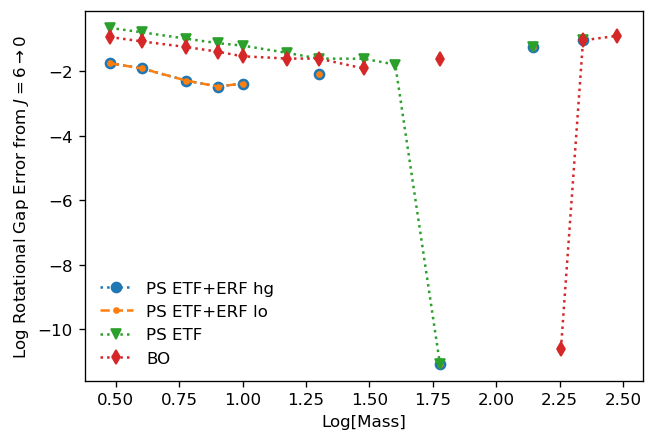

In [783]:
fig,ax = plt.subplots(figsize=(6,4))

# ax.plot(xp.log10(Mass_ex), rot_gap_ex, 'x-', color='k', label='exact')
ax.plot(xp.log10(Mass_ps), xp.log10((rot_gap_ps_hg - rot_gap_ex)/rot_gap_ex), 'o:', label='PS ETF+ERF hg')
ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_ps_lo- rot_gap_ex)/rot_gap_ex), '.--', label='PS ETF+ERF lo')
ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_ps_noerf- rot_gap_ex)/rot_gap_ex), 'v:', label="PS ETF")
ax.plot(xp.log10(Mass_ps),  xp.log10((rot_gap_bo- rot_gap_ex)/rot_gap_ex), "d:", label="BO")

ax.set_xlabel("Log[Mass]")
ax.set_ylabel(r"Log Rotational Gap Error from $J=6\to0$") #, $Log[(E_0(J=6) - E_0(J=0))/E_0(J=0)]$")
ax.legend(frameon=False)
display(fig)

In [920]:
ex2D_Gsq = pd.read_pickle("/home/nb0817/ps-model-exact/2D/test_Gsq_2D/2D_exact.pkl").sort_index(level=0)
ps2D_cpu = pd.read_pickle("/home/nb0817/ps-model-exact/2D/test_Gsq_2D/2D_ps_cpu.pkl").sort_index(level=0)
ps2D_gpu = pd.read_pickle("/home/nb0817/ps-model-exact/2D/test_Gsq_2D/2D_ps_gpu.pkl").sort_index(level=0)
ps2D_Gsq = pd.read_pickle("/home/nb0817/ps-model-exact/2D/test_Gsq_2D/2D_ps_Gsq_fix.pkl").sort_index(level=0)
ps2D_Gsq_nE = pd.read_pickle("/home/nb0817/ps-model-exact/2D/test_Gsq_2D/2D_ps_Gsq_noERF.pkl").sort_index(level=0)
Mass_Gsq = np.sort(np.unique(np.array(ps2D_Gsq.index.to_list())[:,0]))

print(Mass_Gsq)
print(ex2D_Gsq.columns)
print(ps2D_Gsq.columns)

[  3  10  30 100 300]
Index(['gap', 'p01 z', 'p01 r', 'bond length', 'r00', 'r01', 'P01', 'lx00',
       'lx01', 'l200', 'l201', 'p200'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO', 'lx00 PS', 'lx01 PS', 'l200 PS', 'l201 PS',
       'l200 BO', 'l201 BO', 'p200 PS', 'p201 PS'],
      dtype='object')


<IPython.core.display.Javascript object>

/home/nb0817/.conda/envs/xebees/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nb0817/.conda/envs/xebees/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


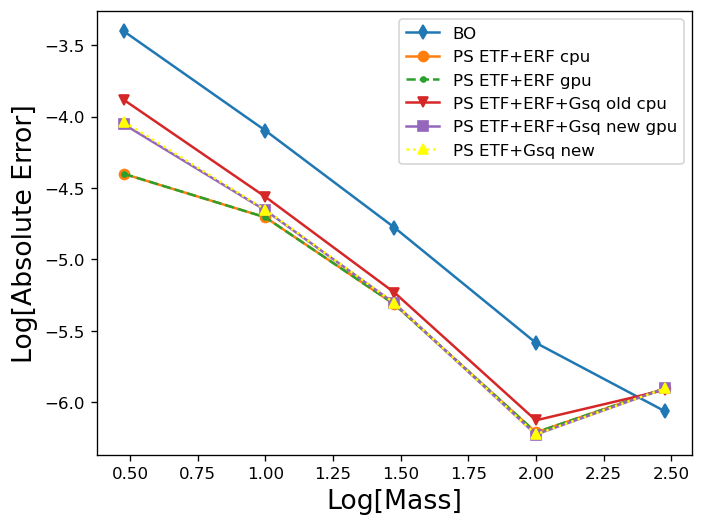

In [921]:
fig, ax = plt.subplots()

# ax.plot(xp.log10(Mass_Gsq), ex2D_Gsq['gap'], 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), ps2D_cpu['gap PS'], 'o-', label='PS')
# ax.plot(xp.log10(Mass_Gsq), ps2D_cpu['gap PSq'], 'v-', label='PS sq')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_Gsq['BO gap']-ex2D_Gsq['gap']), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_cpu['gap PS']-ex2D_Gsq['gap']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_gpu['PS gap']-ex2D_Gsq['gap']), '.--', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_cpu['gap PSq']-ex2D_Gsq['gap']), 'v-', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_Gsq['PS gap']-ex2D_Gsq['gap']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.log10(ps2D_Gsq_nE['PS gap']-ex2D_Gsq['gap']), '^:', label='PS ETF+Gsq new', color='yellow')

ax.set_xlabel("Log[Mass]", fontsize=16)
ax.set_ylabel("Log[Absolute Error]", fontsize=16)
ax.legend()
display(fig)

<IPython.core.display.Javascript object>

Mass  J 
3     10    25.316556- 0.000000j
10    10    25.193415- 0.000000j
30    10    25.310390- 0.000000j
100   10    25.346609- 0.000000j
300   10    25.331896- 0.000000j
Name: l200, dtype: complex128


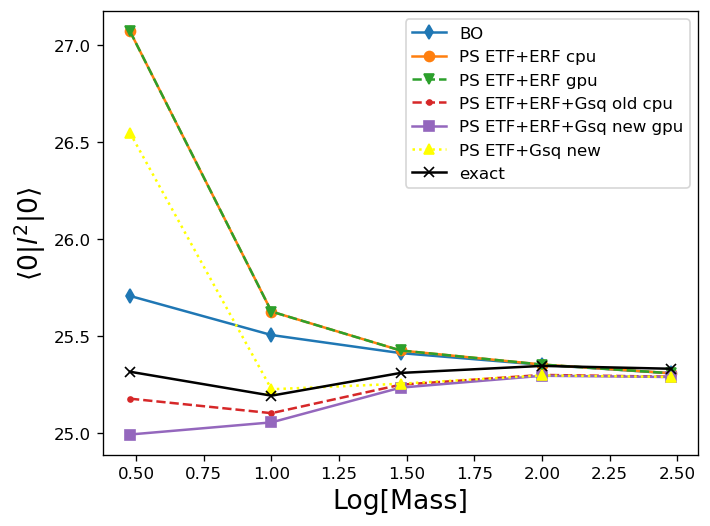

In [925]:
fig,ax = plt.subplots()

# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['l200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PS']), 'x-', label='PS ETF+ERF cpu')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PSq']), 'x-', label='PS ETF+ERF+Gsq old cpu')


# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['p200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PS']), 'x-', label='PS')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PSq']), 'x-', label='PS sq')

ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['l200 BO']), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PS']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['l200 PS']), 'v--', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PSq']), '.--', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['l200 PS']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq_nE['l200 PS']), '^:', label='PS ETF+Gsq new', color='yellow')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['l200']), 'x-', label='exact', color='k')

ax.set_xlabel("Log[Mass]", fontsize=16)
ax.set_ylabel(r"$\langle 0|l^2|0\rangle$", fontsize=16)

print(ex2D_Gsq['l200'])

ax.legend()
display(fig)

<IPython.core.display.Javascript object>

Mass  J 
3     10    25.316556- 0.000000j
10    10    25.193415- 0.000000j
30    10    25.310390- 0.000000j
100   10    25.346609- 0.000000j
300   10    25.331896- 0.000000j
Name: l200, dtype: complex128


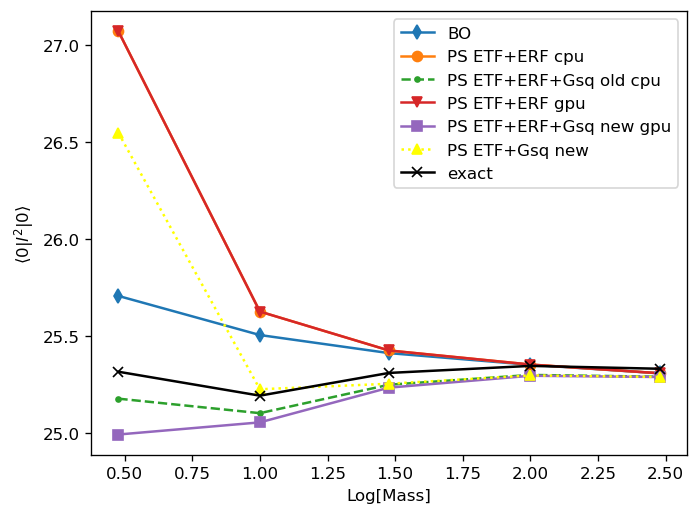

In [926]:
fig,ax = plt.subplots()

# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['l200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PS']), 'x-', label='PS ETF+ERF cpu')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PSq']), 'x-', label='PS ETF+ERF+Gsq old cpu')


# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['p200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PS']), 'x-', label='PS')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PSq']), 'x-', label='PS sq')

ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['l200 BO']), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PS']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PSq']), '.--', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['l200 PS']), 'v-', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['l200 PS']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq_nE['l200 PS']), '^:', label='PS ETF+Gsq new', color='yellow')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['l200']), 'x-', label='exact', color='k')

ax.set_xlabel("Log[Mass]")
ax.set_ylabel(r"$\langle 0|l^2|0\rangle$")

print(ex2D_Gsq['l200'])

ax.legend()
display(fig)

In [924]:
fig,ax = plt.subplots()

ax.plot(xp.log10(Mass_Gsq), xp.abs(xp.asarray(ex2D_Gsq['p01 r']).imag), 'x-', label='exact')
ax.plot(xp.log10(Mass_Gsq), xp.abs(xp.asarray(ps2D_Gsq['p01 x PS'] ).imag), 'x-', label='PS')
ax.plot(xp.log10(Mass_Gsq), xp.abs(xp.asarray(ps2D_Gsq['p01 x PSq']).imag), 'x-', label='PS sq')

ax.set_xlabel("Log[Mass]")
ax.set_ylabel(r"$\langle 1|p_x|0\rangle$")

ax.legend()
display(fig)

<IPython.core.display.Javascript object>

KeyError: 'p01 x PS'

<IPython.core.display.Javascript object>

Mass
3      0.783340+0.000000j
4      0.585447+0.000000j
6      0.388813+0.000000j
8      0.290984+0.000000j
10     0.232455+0.000000j
15     0.154633+0.000000j
20     0.115827+0.000000j
30     0.077102+0.000000j
40     0.057775+0.000000j
60     0.038475+0.000000j
80     0.028837+0.000000j
100    0.023059+0.000000j
140    0.016460+0.000000j
180    0.012797+0.000000j
220    0.010466+0.000000j
300    0.007671+0.000000j
Name: lx00 PS, dtype: complex128


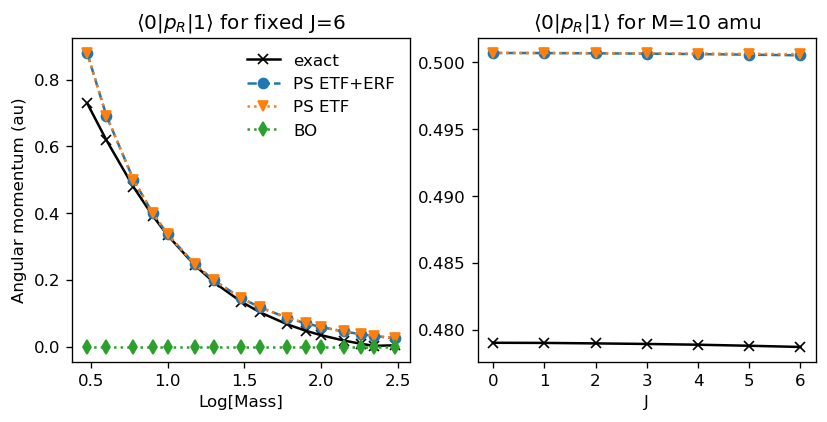

In [931]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3.5))
Ji=6
M=6
# fig.suptitle("l vs Log[Mass] for fixed J={}".format(Ji), fontsize=16)
ax[0].plot(np.log10(Mass_ex), xp.abs(ex3D['p01 r'].loc[(slice(None),Ji)]), 'x-', label='exact', color='k')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_lo['momentum r'].loc[(slice(None)),Ji])), 'o--', label='PS ETF+ERF')
ax[0].plot(np.log10(Mass_Jl) , xp.abs(list(ps3D_noERF['momentum r'].loc[(slice(None)),Ji])), 'v:', label='PS ETF')
ax[0].plot(np.log10(Mass_Jl), xp.zeros(Mass_Jl.size), 'd:', label="BO")
ax[0].set_title(r"$\langle 0 | p_R |1\rangle$ for fixed J=6")
ax[0].set_xlabel("Log[Mass]")
ax[0].set_ylabel("Angular momentum (au)")

ax[1].plot(Js_3D, xp.abs(ex3D['p01 r'].loc[(M,slice(None))]), 'x-', label='exact', color='k')
# ax[1].plot(Js_3D , xp.abs(xp.asarray(ps3D['lx00 PS'].loc[(M,slice(None))]).real), 'o:', label='3D PS ETF+ERF hg')
ax[1].plot(Js_3D , xp.abs((ps3D_lo['momentum r'].loc[(M,slice(None))])), 'o--', label='3D PS ETF+ERF')
ax[1].plot(Js_3D , xp.abs((ps3D_noERF['momentum r'].loc[(M,slice(None))])), 'v:', label='3D PS ETF')
# ax[1].plot(Js_3D , xp.zeros(Js_3D.size), 'd:', label='3D BO')
ax[1].set_title(r"$\langle 0 | p_R |1\rangle$ for M=10 amu")
ax[1].set_xlabel("J")
ax[1].set_xticks(range(7))


ax[0].legend(frameon=False)
print(ps3D_lo['lx00 PS'].loc[(slice(None)),Ji])

display(fig)

In [802]:
ex3D.columns

Index(['gap', 'p01 z', 'p01 r', 'bond length', 'r00', 'r01', 'P01', 'lx00',
       'lx01', 'l200', 'l201', 'E0'],
      dtype='object')

<IPython.core.display.Javascript object>

Mass  J 
3     10    25.316556- 0.000000j
10    10    25.193415- 0.000000j
30    10    25.310390- 0.000000j
100   10    25.346609- 0.000000j
300   10    25.331896- 0.000000j
Name: l200, dtype: complex128


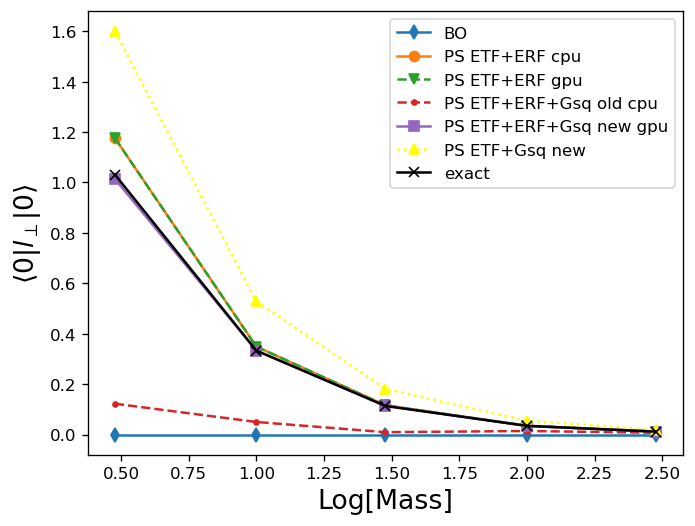

In [927]:
fig,ax = plt.subplots()

# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['l200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PS']), 'x-', label='PS ETF+ERF cpu')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['l200 PSq']), 'x-', label='PS ETF+ERF+Gsq old cpu')


# ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['p200']), 'x-', label='exact')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PS']), 'x-', label='PS')
# ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PSq']), 'x-', label='PS sq')

ax.plot(xp.log10(Mass_Gsq), xp.zeros(Mass_Gsq.size), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['lz00 PS']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['lx00 PS']), 'v--', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['lz00 PSq']), '.--', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['lx00 PS']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq_nE['lx00 PS']), '^:', label='PS ETF+Gsq new', color='yellow')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['lx00']), 'x-', label='exact', color='k')

ax.set_xlabel("Log[Mass]", fontsize=16)
ax.set_ylabel(r"$\langle 0|l_\perp|0\rangle$", fontsize=16)

print(ex2D_Gsq['l200'])

ax.legend()
display(fig)

In [880]:
print(ps2D_cpu.columns)
print(ps2D_gpu.columns)
print(ex2D_Gsq.columns)

Index(['gap PS', 'p01 x PS', 'p01 y PS', 'lz00 PS', 'l200 PS', 'p200 PS',
       'gap PSq', 'p01 x PSq', 'p01 y PSq', 'lz00 PSq', 'l200 PSq',
       'p200 PSq'],
      dtype='object')
Index(['PS gap', 'BO gap', 'momentum z', 'momentum r', 'bond length PS',
       'bond length BO', 'r00 PS', 'r01 PS', 'r00 BO', 'r01 BO', 'P01 PS',
       '(P-G)01 PS', 'P01 BO', 'lx00 PS', 'lx01 PS', 'l200 PS', 'l201 PS',
       'l200 BO', 'l201 BO', 'p200 PS', 'p201 PS'],
      dtype='object')
Index(['gap', 'p01 z', 'p01 r', 'bond length', 'r00', 'r01', 'P01', 'lx00',
       'lx01', 'l200', 'l201', 'p200'],
      dtype='object')


<IPython.core.display.Javascript object>

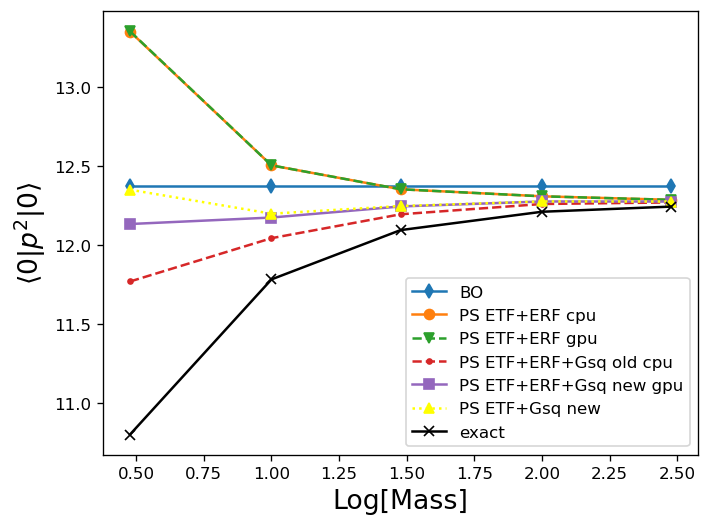

In [928]:
fig,ax = plt.subplots()
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['p200 BO']), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['p200 PS']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['p200 PS']), 'v--', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['p200 PSq']), '.--', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['p200 PS']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq_nE['p200 PS']), '^:', label='PS ETF+Gsq new', color='yellow')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['p200'])/mu*mur, 'x-', label='exact', color='k')

ax.set_ylabel(r"$\langle 0 |p^2|0\rangle$", fontsize=16)
ax.set_xlabel("Log[Mass]", fontsize=16)
ax.legend()

display(fig)

In [908]:
m1 = 1e6*1836
m2 = Mass_Gsq*1836
me = 1*1836

mu12 = m1*m2/(m1+m2)
mur = me*(m1+m2)/(me+m1+m2)
mu = xp.sqrt(me*m1*m2/(m1+m2+me))

print(mur)
print(mu)
print(mu/mur)

[1835.99816401 1835.99816402 1835.99816406 1835.99816419 1835.99816455]
[ 3180.03892262  5805.90985165 10056.03028853 18359.07289023
 31795.66793898]
[ 1.73204908  3.16226343  5.47714616  9.99950504 17.31791924]


<IPython.core.display.Javascript object>

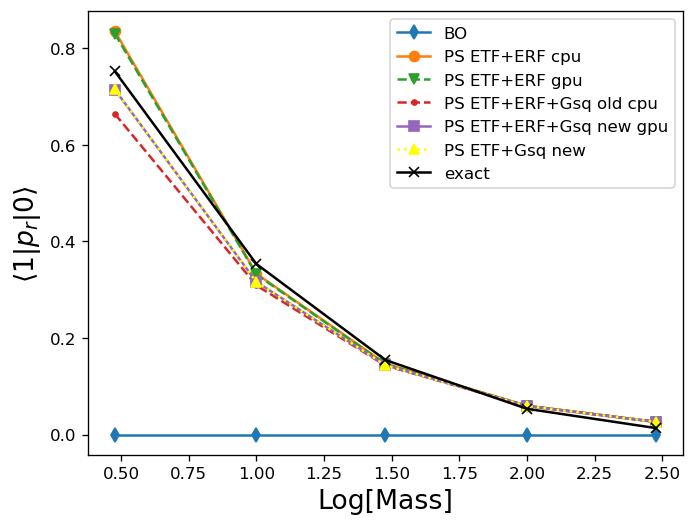

In [918]:
fig,ax = plt.subplots()
ax.plot(xp.log10(Mass_Gsq), xp.zeros(Mass_Gsq.size), 'd-', label='BO')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['p01 x PS']), 'o-', label='PS ETF+ERF cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_gpu['momentum r']), 'v--', label='PS ETF+ERF gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_cpu['p01 x PSq']), '.--', label='PS ETF+ERF+Gsq old cpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq['momentum r']), 's-', label='PS ETF+ERF+Gsq new gpu')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ps2D_Gsq_nE['momentum r']), '^:', label='PS ETF+Gsq new', color='yellow')
ax.plot(xp.log10(Mass_Gsq), xp.abs(ex2D_Gsq['p01 r']), 'x-', label='exact', color='k')

ax.set_ylabel(r"$\langle 1 |p_r|0\rangle$", fontsize=16)
ax.set_xlabel("Log[Mass]", fontsize=16)
ax.legend()

display(fig)

In [937]:
ps3D_lo['lx00 PS'].loc[(100,list(range(7)))]

Mass  J  
100   0.0    1.305695e-09+5.016319e-                    14j
      1.0    5.031753e-03+5.015888e-                    14j
      2.0    8.715393e-03+5.015155e-                    14j
      3.0    1.232542e-02+5.016465e-                    14j
      4.0    1.591200e-02+5.017078e-                    14j
      5.0    1.948832e-02+5.015594e-                    14j
      6.0    2.305902e-02+5.016786e-                    14j
Name: lx00 PS, dtype: complex128

In [938]:
ps3D_lo['l200 PS'].loc[(100,list(range(7)))]

Mass  J  
100   0.0    51.490924+ 0.000000j
      1.0    51.491012- 0.000000j
      2.0    51.491189- 0.000000j
      3.0    51.491458- 0.000000j
      4.0    51.491813+ 0.000000j
      5.0    51.492259+ 0.000000j
      6.0    51.492794- 0.000000j
Name: l200 PS, dtype: complex128

In [939]:
ex3D['l200'].loc[(100,list(range(7)))]

Mass  J  
100   0.0    51.398804+ 0.000000j
      1.0    51.398861+ 0.000000j
      2.0    51.399061+ 0.000000j
      3.0    51.399327+ 0.000000j
      4.0    51.399697+ 0.000000j
      5.0    51.400128+ 0.000000j
      6.0    51.400661+ 0.000000j
Name: l200, dtype: complex128